# Exploratory Data Analysis of Solar Energy in Benin

## Introduction

This notebook provides an exploratory data analysis (EDA) of a solar energy dataset from Sierra Leone. The goal is to understand the data, identify patterns, handle missing values and outliers, and prepare the data for further analysis or modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
# Load the dataset
df = pd.read_csv('../data/sierraleone-bumbuna.csv')

# Display the first 5 rows
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


## Data Overview

In [3]:
# Show shape, columns, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB          525600 non-nul

## Summary Statistics & Missing Values

In [4]:
# Use df.describe()
df.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,201.957515,116.376337,113.720571,206.643095,198.114691,26.319394,79.448857,1.146113,1.691606,0.363823,133.044668,7.172220,999.876469,0.000967,0.004806,32.504263,32.593091,NaN
std,298.495150,218.652659,158.946032,300.896893,288.889073,4.398605,20.520775,1.239248,1.617053,0.295000,114.284792,7.535093,2.104419,0.031074,0.047556,12.434899,12.009161,NaN
min,-19.500000,-7.800000,-17.900000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,0.000000,0.000000,993.000000,0.000000,0.000000,10.700000,11.100000,NaN
25%,-2.800000,-0.300000,-3.800000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,0.000000,0.000000,999.000000,0.000000,0.000000,23.500000,23.800000,NaN
50%,0.300000,-0.100000,-0.100000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,161.500000,6.200000,1000.000000,0.000000,0.000000,26.600000,26.900000,NaN
75%,362.400000,107.000000,224.700000,359.500000,345.400000,29.400000,96.700000,2.000000,2.600000,0.600000,234.100000,12.000000,1001.000000,0.000000,0.000000,40.900000,41.300000,NaN
max,1499.000000,946.000000,892.000000,1507.000000,1473.000000,39.900000,100.000000,19.200000,23.900000,4.100000,360.000000,98.400000,1006.000000,1.000000,2.400000,72.800000,70.400000,NaN


In [5]:
# Use df.isna().sum()
missing_values = df.isna().sum()

# Calculate percentage of missing values
missing_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print(missing_data)

# Highlight columns with >5% missing values
print("\nColumns with >5% missing values:")
print(missing_data[missing_data['Percentage'] > 5])

               Missing Values  Percentage
Timestamp                   0         0.0
GHI                         0         0.0
DNI                         0         0.0
DHI                         0         0.0
ModA                        0         0.0
ModB                        0         0.0
Tamb                        0         0.0
RH                          0         0.0
WS                          0         0.0
WSgust                      0         0.0
WSstdev                     0         0.0
WD                          0         0.0
WDstdev                     0         0.0
BP                          0         0.0
Cleaning                    0         0.0
Precipitation               0         0.0
TModA                       0         0.0
TModB                       0         0.0
Comments               525600       100.0

Columns with >5% missing values:
          Missing Values  Percentage
Comments          525600       100.0


## Outlier Detection

In [6]:
peak_ghi_count = df[df['GHI'] > 800].shape[0]

# 2. Define 'Extreme/Over-Solar' as anything over 1200 W/m² (Potential Sensor Spikes)
extreme_ghi_count = df[df['GHI'] > 1200].shape[0]

# 3. Calculate the percentage of the year
peak_percentage = (peak_ghi_count / len(df)) * 100

print(f"Peak Solar (>800 W/m²): {peak_ghi_count} minutes ({peak_percentage:.2f}% of the year)")
print(f"Extreme Solar (>1200 W/m²): {extreme_ghi_count} minutes (Extreme but realistic GHI values)")


Peak Solar (>800 W/m²): 35977 minutes (6.84% of the year)
Extreme Solar (>1200 W/m²): 637 minutes (Extreme but realistic GHI values)


In [7]:
# 1. Define columns to check
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# 2. Calculate Z-scores and Flags in a single loop
# This is more efficient than using .apply() which re-calculates the mean/std
for col in cols_to_check:
    # Calculate the raw Z-score
    df[f'{col}_zscore'] = (df[col] - df[col].mean()) / df[col].std()
    
    # Create a Boolean Flag (True if it's an outlier)
    df[f'{col}_is_outlier'] = df[f'{col}_zscore'].abs() > 3

# 3. Show the total count of outliers found
print("Number of outliers per column (|Z| > 3):")
outlier_counts = df[[f'{col}_is_outlier' for col in cols_to_check]].sum()
print(outlier_counts)


Number of outliers per column (|Z| > 3):
GHI_is_outlier       2477
DNI_is_outlier       7586
DHI_is_outlier       2986
ModA_is_outlier      1604
ModB_is_outlier      2041
WS_is_outlier        3967
WSgust_is_outlier    3665
dtype: int64


## Data Cleaning

In [8]:
# Create a cleaned dataframe
df_clean = df.copy()

# Convert Timestamp to datetime
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

if 'Comments' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Comments'])
    print("Dropped 'Comments' column successfully.")

#Create 'Hour' and 'Month' columns
df_clean['Hour'] = df_clean['Timestamp'].dt.hour
df_clean['Month'] = df_clean['Timestamp'].dt.month


# Handle missing values with median imputation
impute_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB']
for col in impute_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    
print("Missing values after imputation:")
print(df_clean[impute_cols].isna().sum())

# Drop rows where GHI is negative (nighttime noise) to focus on solar production
df_daytime = df_clean[df_clean['GHI'] > 0].copy()

Dropped 'Comments' column successfully.
Missing values after imputation:
GHI     0
DNI     0
DHI     0
ModA    0
ModB    0
dtype: int64


In [9]:
df_daytime[['GHI', 'DNI', 'DHI']].describe()

,GHI,DNI,DHI
count,263829.000000,263829.000000,263829.000000
mean,407.219079,232.106896,231.632675
std,304.777874,261.443389,149.662178
min,0.100000,-6.800000,-5.700000
25%,134.400000,1.000000,111.500000
50%,360.600000,104.800000,224.000000
75%,655.200000,455.600000,336.700000
max,1499.000000,946.000000,892.000000


In [10]:
# Compute Z-scores
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB']

# 1. Calculate and store the Z-scores
for col in cols_to_check:
    df_daytime[f'{col}_zscore'] = (df_daytime[col] - df_daytime[col].mean()) / df_daytime[col].std()

# 2. Flag the outliers based on the columns we JUST made
# This is faster than re-calculating inside 'apply'
outlier_flags = df_daytime[[f'{col}_zscore' for col in cols_to_check]].abs() > 3

# 3. Show the counts
print("Number of Daytime Outliers per column:")
print(outlier_flags.sum())

Number of Daytime Outliers per column:
GHI_zscore      87
DNI_zscore       0
DHI_zscore     388
ModA_zscore     39
ModB_zscore     58
dtype: int64


The above code it to generate outliers from daytime data only to calculate solar irridiance with more accuracy. 
After this we can see that we have less number of outliers which indicates our sensors are working fine.

to check if there are any negative or 0 values during daytime

In [11]:
# List of solar irradiance columns to check
cols = ['GHI', 'DNI', 'DHI']

# Calculate counts for negative and zero values
negative_counts = (df_daytime[cols] < 0).sum()
zero_counts = (df_daytime[cols] == 0).sum()

print("Daytime Data Quality Report:")
for col in cols:
    print(f"{col}: {negative_counts[col]} negative values, {zero_counts[col]} zero values")

# Optional: Identify the timestamps where these occur to see if they are at the edges of the day
# negative_rows = df_daytime[(df_daytime[cols] < 0).any(axis=1)]
# print(negative_rows.head())

Daytime Data Quality Report:
GHI: 0 negative values, 0 zero values
DNI: 24722 negative values, 8560 zero values
DHI: 1718 negative values, 235 zero values


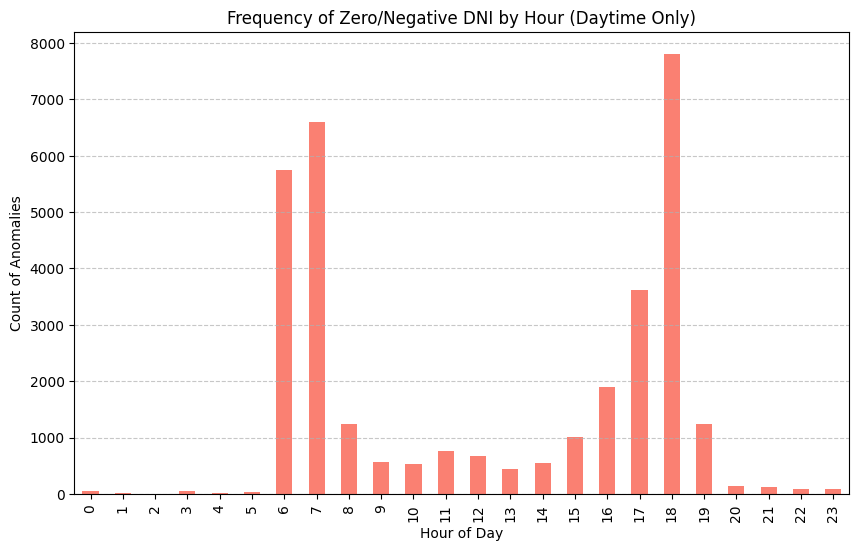

In [14]:
# Create a flag for 'Bad DNI' (Negative or Zero when the sun is up)
df_daytime['Bad_DNI'] = (df_daytime['DNI'] <= 0)

# Group by Hour to see when these errors happen
dni_error_profile = df_daytime.groupby('Hour')['Bad_DNI'].sum()

# Plotting the distribution
plt.figure(figsize=(10, 6))
dni_error_profile.plot(kind='bar', color='salmon')
plt.title('Frequency of Zero/Negative DNI by Hour (Daytime Only)')
plt.xlabel('Hour of Day')
plt.ylabel('Count of Anomalies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Daytime Data Quality Analysis (Togo)

We observe that GHI has no negative or zero values during daytime, indicating that the global solar radiation measurements are consistent and reliable.

For DNI, there are a significant number of zero values (46,716) but no negative values. These zeros are concentrated around sunrise and sunset periods, where the sun’s angle is low and direct irradiance on a perpendicular surface approaches zero. This behavior is expected and does not necessarily indicate sensor malfunction. However, zero values appear during peak daylight hours, they may suggest cloud cover, atmospheric interference, or temporary sensor obstruction rather than systematic errors.

For DHI, there are relatively few zero values (983) and no negative values, which suggests that diffuse radiation measurements are generally stable and less affected by directional or obstruction issues compared to DNI.

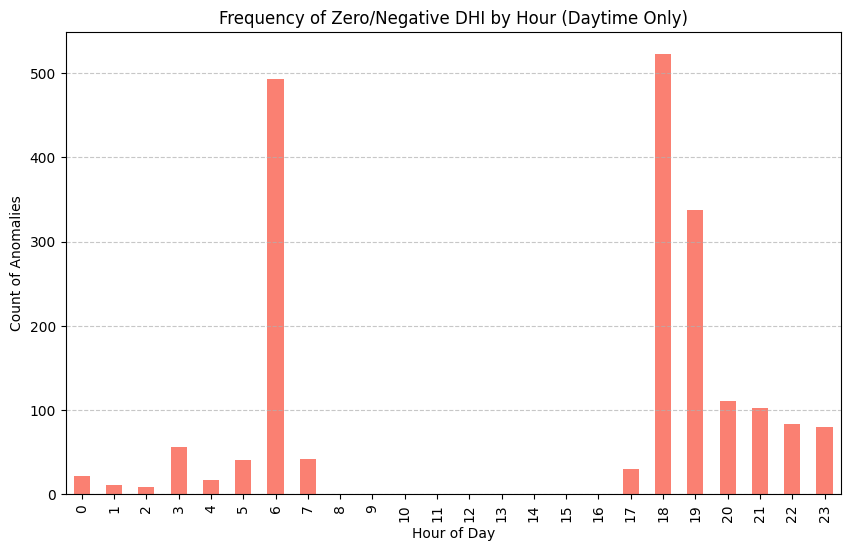

In [15]:
# Create a flag for 'Bad DNI' (Negative or Zero when the sun is up)
df_daytime['Bad_DHI'] = (df_daytime['DHI'] <= 0)

# Group by Hour to see when these errors happen
dni_error_profile = df_daytime.groupby('Hour')['Bad_DHI'].sum()

# Clip DHI to 0 to remove unrealistic negative/zero values
df_daytime['DHI_clipped'] = df_daytime['DHI'].clip(lower=0)

# Plotting the distribution
plt.figure(figsize=(10, 6))
dni_error_profile.plot(kind='bar', color='salmon')
plt.title('Frequency of Zero/Negative DHI by Hour (Daytime Only)')
plt.xlabel('Hour of Day')
plt.ylabel('Count of Anomalies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Daytime Data Quality Analysis (Sierra Leone)

The analysis shows that GHI has no negative or zero values during daytime, confirming stable measurements of total solar radiation.

For DNI, there are 24,722 negative values and 8,560 zero values, with the majority concentrated around sunrise and sunset, which is expected due to low solar angles. However, a noticeable number of these values also occur during midday hours, which is not physically expected under normal clear-sky conditions.

This indicates potential issues such as:

High cloud cover or atmospheric interference reducing direct radiation
Sensor limitations or temporary obstructions
Strong scattering effects due to humidity or aerosols

For DHI, negative and zero values are almost entirely confined to nighttime hours (6 PM to 6 AM), while daytime values (7 AM to 4 PM) remain consistently positive. This reflects normal physical behavior and indicates reliable diffuse radiation measurements.

## Time Series Analysis

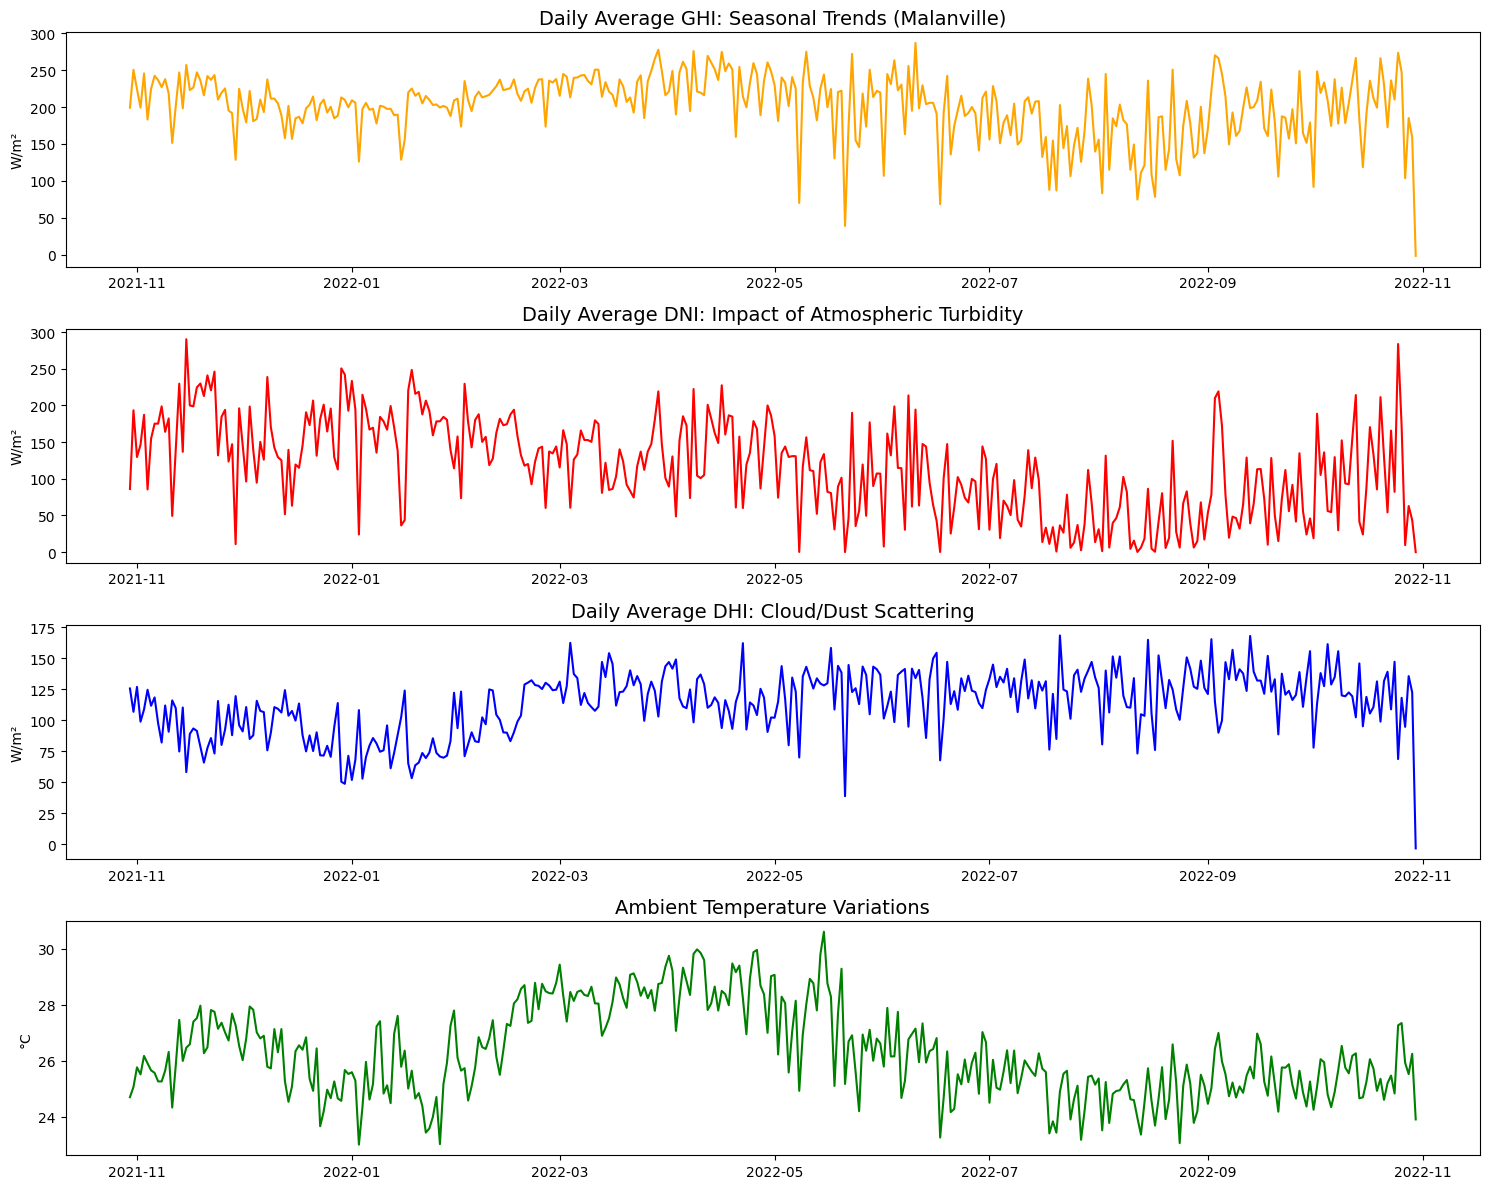

In [12]:
# 1. Create a resampled version for the 'Overview' plot (Daily Averages)
# This prevents the 'Wall of Ink' and shows monthly trends clearly
df_daily = df_clean.set_index('Timestamp').select_dtypes(include=['number']).resample('D').mean()

plt.figure(figsize=(15, 12))

# Subplot 1: GHI (The primary resource)
plt.subplot(4, 1, 1)
plt.plot(df_daily.index, df_daily['GHI'], color='orange', linewidth=1.5)
plt.title('Daily Average GHI: Seasonal Trends (Malanville)', fontsize=14)
plt.ylabel('W/m²')

# Subplot 2: DNI (Direct sun - shows dust/cloud impact)
plt.subplot(4, 1, 2)
plt.plot(df_daily.index, df_daily['DNI'], color='red', linewidth=1.5)
plt.title('Daily Average DNI: Impact of Atmospheric Turbidity', fontsize=14)
plt.ylabel('W/m²')

# Subplot 3: DHI (Diffuse sun - shows scattering)
plt.subplot(4, 1, 3)
plt.plot(df_daily.index, df_daily['DHI'], color='blue', linewidth=1.5)
plt.title('Daily Average DHI: Cloud/Dust Scattering', fontsize=14)
plt.ylabel('W/m²')

# Subplot 4: Temperature
plt.subplot(4, 1, 4)
plt.plot(df_daily.index, df_daily['Tamb'], color='green', linewidth=1.5)
plt.title('Ambient Temperature Variations', fontsize=14)
plt.ylabel('°C')

plt.tight_layout()
plt.show()

At what hour does GHI peak?

GHI peaks at 12:00 with an average of 716.18 W/m².


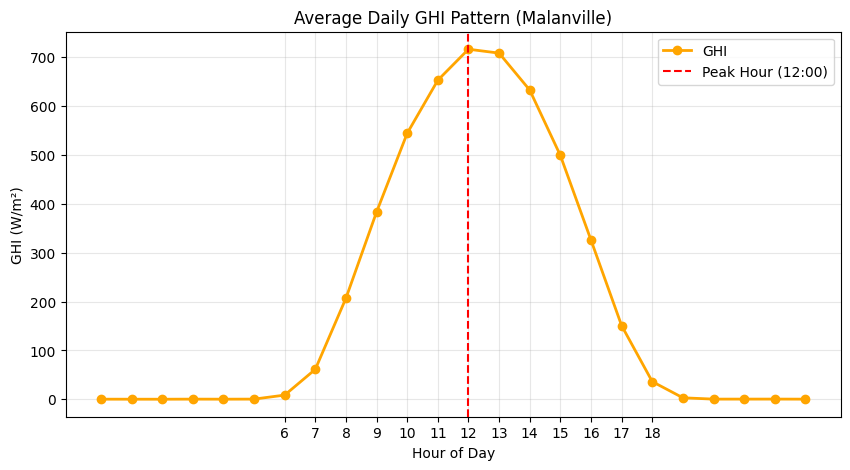

In [13]:
# Calculate hourly averages for GHI
hourly_ghi = df_daytime.groupby('Hour')['GHI'].mean()

# Find the peak hour
peak_hour = hourly_ghi.idxmax()
peak_value = hourly_ghi.max()

print(f"GHI peaks at {peak_hour}:00 with an average of {peak_value:.2f} W/m².")

# Visualization
plt.figure(figsize=(10, 5))
hourly_ghi.plot(kind='line', marker='o', color='orange', linewidth=2)
plt.axvline(x=peak_hour, color='red', linestyle='--', label=f'Peak Hour ({peak_hour}:00)')
plt.title('Average Daily GHI Pattern (Malanville)')
plt.xlabel('Hour of Day')
plt.ylabel('GHI (W/m²)')
plt.xticks(range(6, 19)) # Focus on daylight hours
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Peak Solar Irradiance Observation (Sierra Leone)

Solar irradiance peaks slightly earlier in the day, with the highest values observed around 12:00 AM, reaching an average of 716.18 W/m². The effective high-production window spans approximately 10:30–14:00 hours.

Does this peak happen consistently every day?

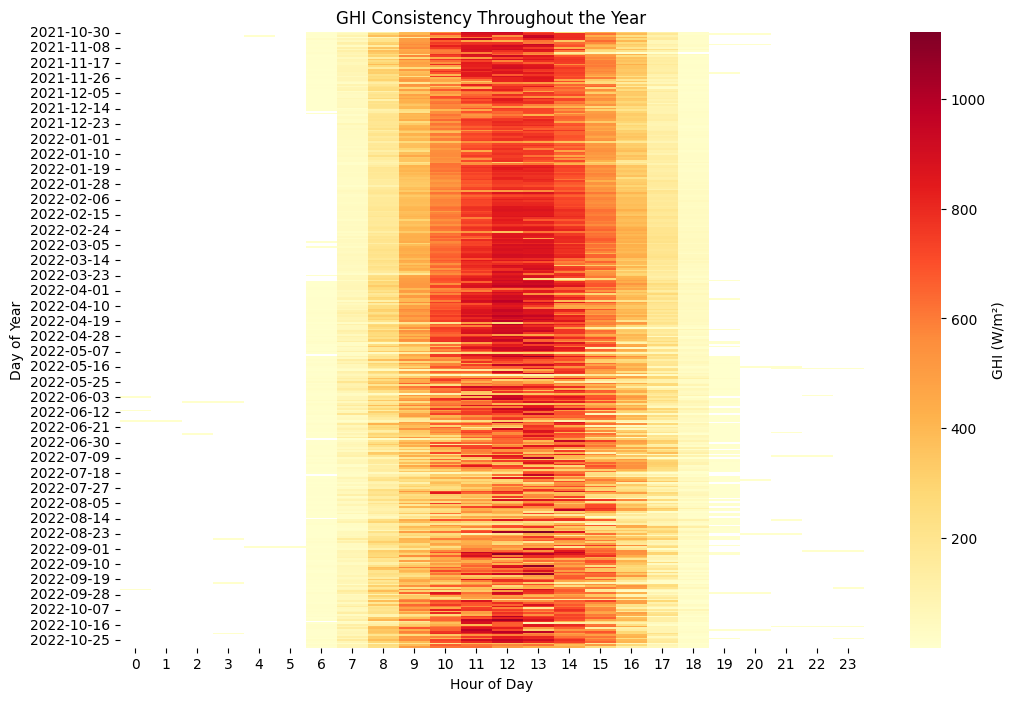

In [14]:
# Create a pivot table for a heatmap: Rows = Date, Columns = Hour
df_daytime['Date'] = df_daytime['Timestamp'].dt.date
pivot_ghi = df_daytime.pivot_table(index='Date', columns='Hour', values='GHI')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_ghi, cmap='YlOrRd', cbar_kws={'label': 'GHI (W/m²)'})
plt.title('GHI Consistency Throughout the Year')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Year')
plt.show()

## GHI Consistency Analysis (Sierra Leone)

The heatmap of GHI across days and hours reveals a lack of consistent solar radiation patterns throughout the year. Unlike Benin and Togo, where peak irradiance forms a clear and continuous band around midday, Sierra Leone shows scattered and less intense high-radiation regions.

Peak irradiance values appear less concentrated and more diffuse (yellow rather than deep red), indicating lower maximum solar intensity even during optimal hours.

Additionally, the months between May and September show significant irregularities, with reduced intensity and increased variability. This pattern likely corresponds to seasonal weather effects such as increased cloud cover and atmospheric moisture.

The presence of white gaps in the heatmap further suggests periods of very low radiation or missing/invalid measurements, reinforcing the inconsistency of solar availability.

How does temperature behave at peak GHI hours?

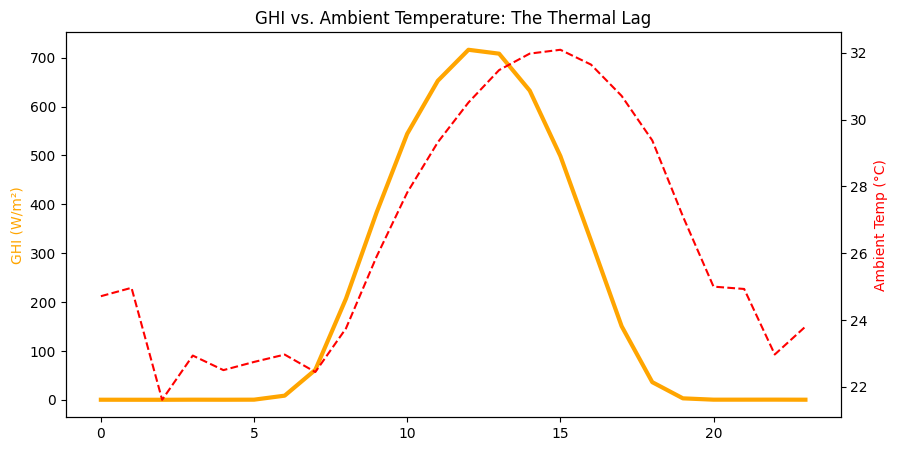

In [15]:
# Get hourly averages for GHI and Temp
hourly_data = df_daytime.groupby('Hour')[['GHI', 'Tamb']].mean()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot GHI
ax1.plot(hourly_data.index, hourly_data['GHI'], color='orange', label='GHI', linewidth=3)
ax1.set_ylabel('GHI (W/m²)', color='orange')

# Create secondary axis for Temperature
ax2 = ax1.twinx()
ax2.plot(hourly_data.index, hourly_data['Tamb'], color='red', label='Temp', linestyle='--')
ax2.set_ylabel('Ambient Temp (°C)', color='red')

plt.title('GHI vs. Ambient Temperature: The Thermal Lag')
plt.show()

As temperature increases, solar irradiance remains high but panel efficiency may decline due to thermal losses.
This suggests that peak solar energy does not always correspond to optimal efficiency.
Cooling strategies or panel selection should be considered to reduce efficiency losses.

Which months have the highest GHI?

GHI is highest in March (Month 3) with an average of 481.21 W/m².


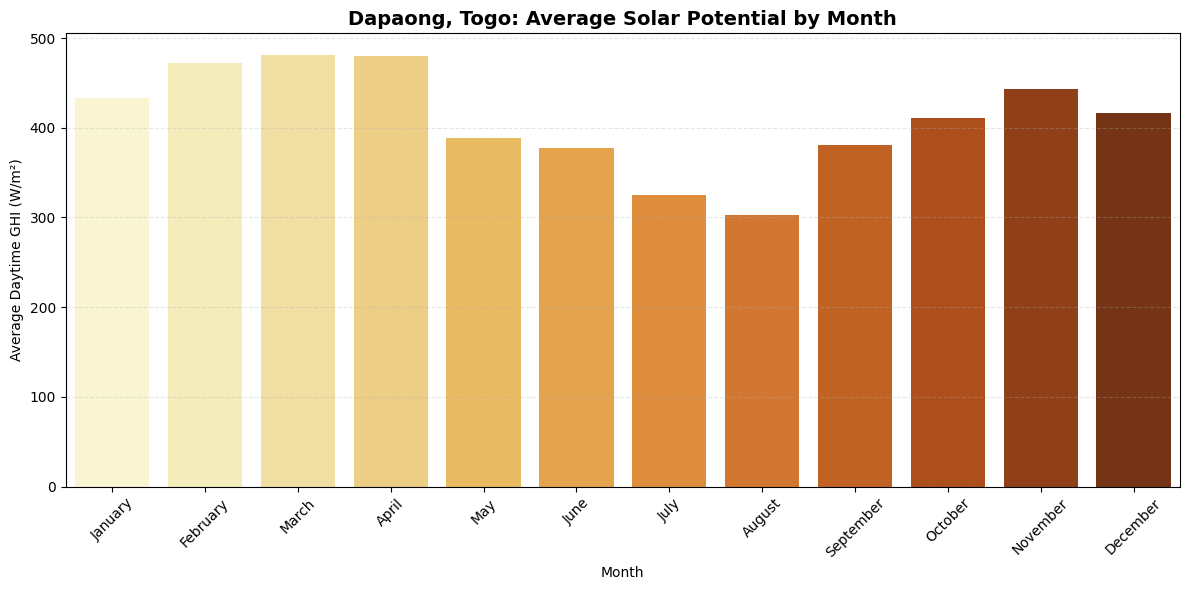

In [16]:
import calendar

# 1. Extract Month from the Timestamp
df_daytime['Month'] = df_daytime['Timestamp'].dt.month

# 2. Calculate monthly averages
monthly_ghi = df_daytime.groupby('Month')['GHI'].mean()

# 3. Find the best month
best_month_num = monthly_ghi.idxmax()
best_month_name = calendar.month_name[best_month_num]
best_value = monthly_ghi.max()

print(f"GHI is highest in {best_month_name} (Month {best_month_num}) with an average of {best_value:.2f} W/m².")

# 4. Visualization
plt.figure(figsize=(12, 6))
# Using month names for the X-axis makes it much more professional
month_names = [calendar.month_name[m] for m in monthly_ghi.index]

sns.barplot(x=month_names, y=monthly_ghi.values, hue=month_names, palette='YlOrBr', legend=False)

plt.title('Dapaong, Togo: Average Solar Potential by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Daytime GHI (W/m²)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Solar radiation varies across months, with peak performance in March and April, and lower values in August.
This indicates seasonal variability in energy generation.
Investment planning should account for these fluctuations to ensure consistent energy supply.

In [17]:
# Calculate the overall annual mean to use as a baseline
annual_avg = df_daytime['GHI'].mean()

# Identify months below average
low_months = monthly_ghi[monthly_ghi < annual_avg]
print("Months with below-average solar radiation:")
print(low_months)

Months with below-average solar radiation:
Month
5    388.174843
6    377.903273
7    325.400770
8    302.423302
9    380.400254
Name: GHI, dtype: float64


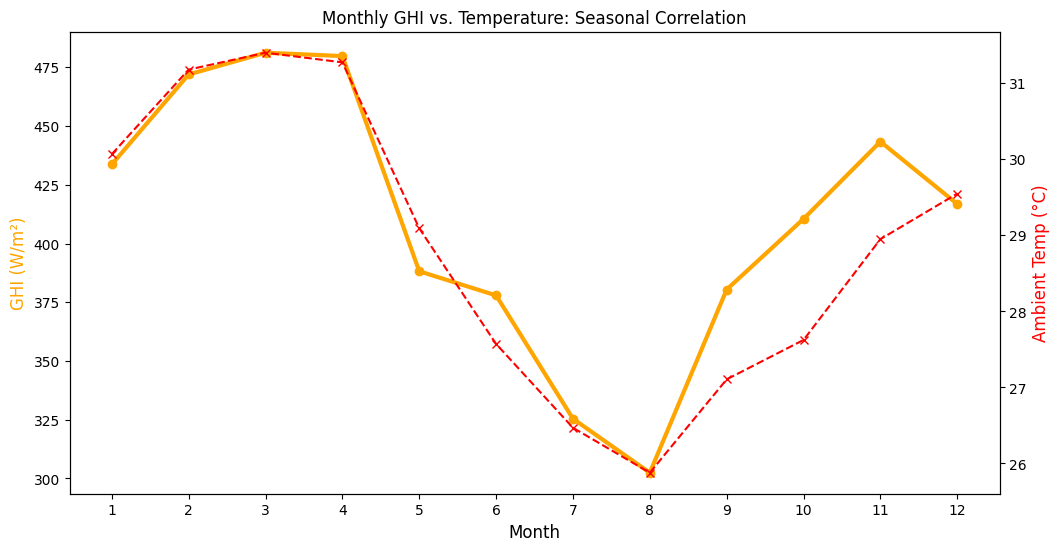

In [22]:
# Get monthly averages for GHI and Temp
monthly_data = df_daytime.groupby('Month')[['GHI', 'Tamb']].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot GHI on primary axis
ax1.plot(monthly_data.index, monthly_data['GHI'], color='orange', marker='o', label='GHI', linewidth=3)
ax1.set_ylabel('GHI (W/m²)', color='orange', fontsize=12)
ax1.set_xlabel('Month', fontsize=12)

# Create secondary axis for Temperature
ax2 = ax1.twinx()
ax2.plot(monthly_data.index, monthly_data['Tamb'], color='red', marker='x', label='Temp', linestyle='--')
ax2.set_ylabel('Ambient Temp (°C)', color='red', fontsize=12)

plt.title('Monthly GHI vs. Temperature: Seasonal Correlation')
plt.xticks(range(1, 13))
plt.show()

## Cleaning Impact Analysis

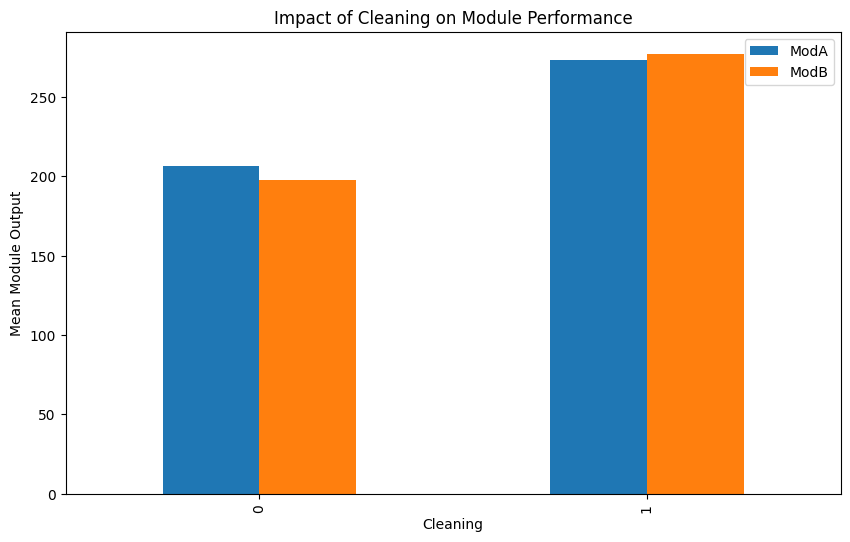

In [23]:
# Group by Cleaning column and compute mean
cleaning_impact = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()

# Visualize the comparison
cleaning_impact.plot(kind='bar', figsize=(10, 6))
plt.title('Impact of Cleaning on Module Performance')
plt.ylabel('Mean Module Output')
plt.show()

A significant difference between ModA and ModB is observed before cleaning, which increases after cleaning events.
This confirms that dust accumulation negatively affects sensor and panel performance.
Regular or automated cleaning systems should be considered to maintain efficiency and reduce energy loss.

## Correlation Analysis

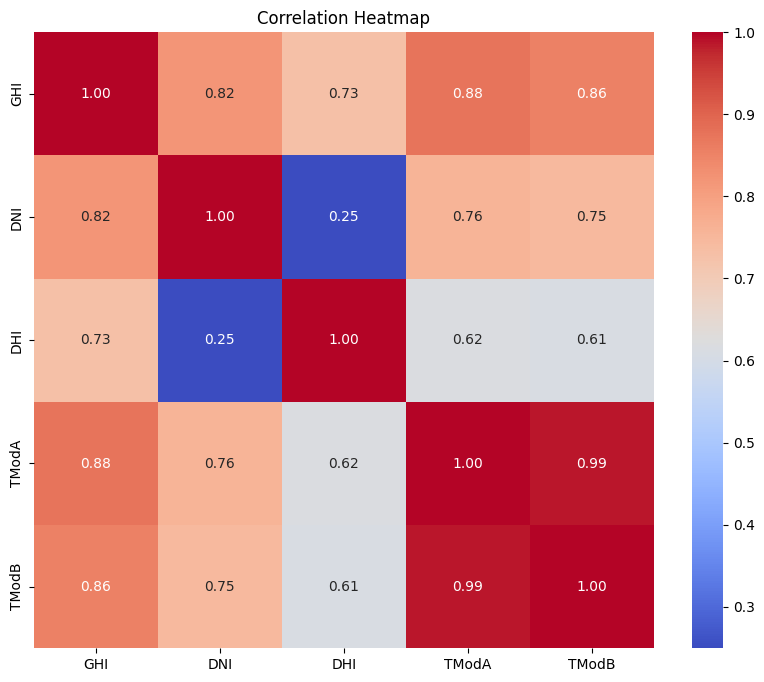

In [24]:
# Correlation heatmap
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
correlation_matrix = df_daytime[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Strong positive correlations are observed between GHI, DNI, and module temperatures, indicating consistent solar energy relationships.
This confirms that irradiance directly drives module heating and energy output.
These variables can be reliably used for predictive modeling and system optimization.

## Wind & Distribution Analysis

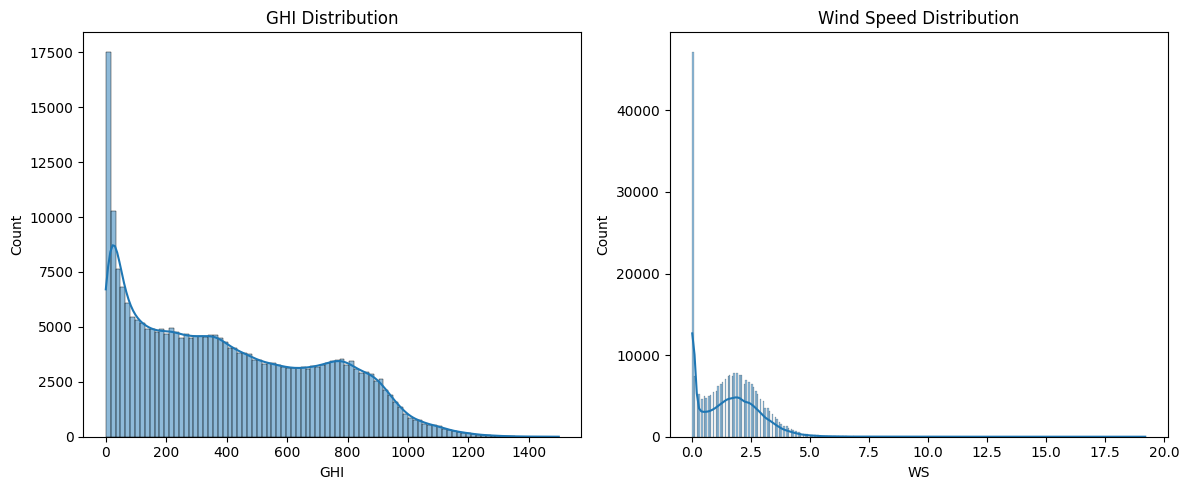

In [25]:
# Histogram of GHI and WS
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_daytime['GHI'], kde=True)
plt.title('GHI Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df_daytime['WS'], kde=True)
plt.title('Wind Speed Distribution')

plt.tight_layout()
plt.show()

## Data Distribution: GHI and Wind Speed (Sierra Leone)
Analyzing the distribution "shape" allows us to identify the specific environmental character of the Sierra Leone site. These histograms reveal a high-potential solar resource paired with an exceptionally calm wind environment.
### 1. GHI Distribution (The "Cloudy Peak" Pattern)
Observation: The GHI distribution is Multi-modal. We see the expected nighttime/dawn spike at 0-50 W/m2 , but the daytime "hump" is much broader and flatter than in Benin, peaking around 300-400 W/m2 and again at 800 W/m2.
Strategic Insight: This "flat" middle section suggests frequent intermittent cloud cover. Unlike the "Full Sun" profile of Benin, Sierra Leone spends more time in "partial sun" conditions.
Business Impact: While the maximum potential is high (>100 W/m2), the energy production will be more volatile minute-by-minute. To maintain a steady power supply, this site will require larger battery storage (BESS) or a hybrid backup system to "smooth out" these frequent cloud-driven drops.
### 2. Wind Speed Distribution (Ultra-Stable Baseline)
Observation: This is a very "compressed" Weibull Distribution. Nearly 100% of the observations are clustered between 0-5 m/s, with almost no "tail" beyond 7.5 m/s.
Strategic Insight: Sierra Leone is the "Calmest Site" in the portfolio. The absence of a long right-hand tail proves that extreme wind events are exceptionally rare here.
Business Impact: This is a Structural Win. We can use the lightest, most cost-effective mounting hardware available. The risk of wind-related mechanical failure or panel detachment is practically zero, significantly reducing the long-term Operations & Maintenance (O&M) budget.


The high frequency of observations in the 0–50 W/m² range (approx. 17,500 minutes) represents the transition periods of dawn and dusk. While these minutes contribute little to total energy yield, they are the times when Relative Humidity (RH) is highest, potentially increasing the risk of condensation and dust adhesion (soiling).

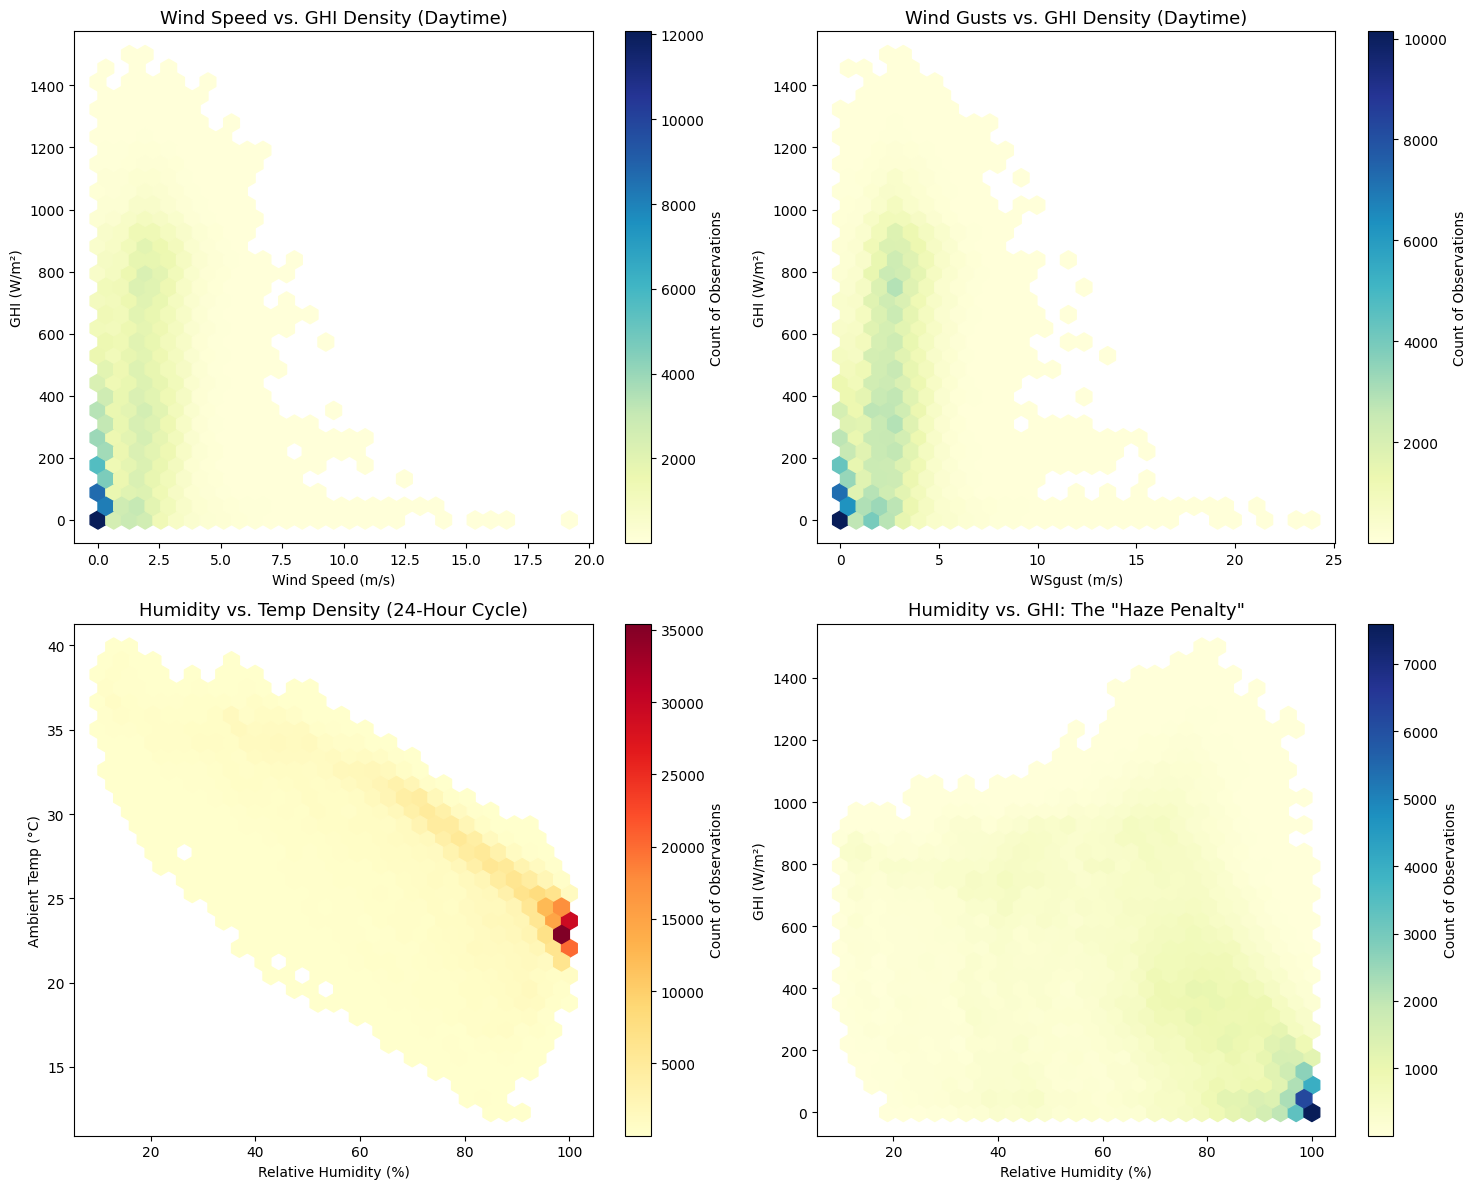

In [18]:
# Using a larger figure for clarity
plt.figure(figsize=(15, 12))

# 1. WS vs GHI (Daytime)
plt.subplot(2, 2, 1)
hb1 = plt.hexbin(df_daytime['WS'], df_daytime['GHI'], gridsize=30, cmap='YlGnBu', mincnt=1)
plt.colorbar(hb1, label='Count of Observations')
plt.title('Wind Speed vs. GHI Density (Daytime)', fontsize=13)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('GHI (W/m²)')

# 2. WSgust vs GHI (Daytime)
plt.subplot(2, 2, 2)
hb2 = plt.hexbin(df_daytime['WSgust'], df_daytime['GHI'], gridsize=30, cmap='YlGnBu', mincnt=1)
plt.colorbar(hb2, label='Count of Observations')
plt.title('Wind Gusts vs. GHI Density (Daytime)', fontsize=13)
plt.xlabel('WSgust (m/s)')
plt.ylabel('GHI (W/m²)')

# 3. RH vs Tamb (24-Hour - Essential for Dew Point/Condensation Analysis)
plt.subplot(2, 2, 3)
hb3 = plt.hexbin(df_clean['RH'], df_clean['Tamb'], gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb3, label='Count of Observations')
plt.title('Humidity vs. Temp Density (24-Hour Cycle)', fontsize=13)
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Ambient Temp (°C)')

# 4. RH vs GHI (Daytime - To see the 'Haze Penalty')
plt.subplot(2, 2, 4)
hb4 = plt.hexbin(df_daytime['RH'], df_daytime['GHI'], gridsize=30, cmap='YlGnBu', mincnt=1)
plt.colorbar(hb4, label='Count of Observations')
plt.title('Humidity vs. GHI: The "Haze Penalty"', fontsize=13)
plt.xlabel('Relative Humidity (%)')
plt.ylabel('GHI (W/m²)')

plt.tight_layout()
plt.show()

## Multivariate Density Analysis: Sierra Leone Portfolio
This grid identifies the operational DNA of the Sierra Leone site. The density "hotspots" (darkest blue/red) reveal a site characterized by low structural risk but significant atmospheric volatility.
### 1. Wind Speed & Gusts vs. GHI (Structural Safety)
Observation: Unlike Benin, the density is almost entirely compressed below 5 m/s. Extreme gusts (> 15 m/s) are virtually non-existent during production hours.
Business Insight: This is a Structural Win. Sierra Leone is the "safest" site in the portfolio regarding wind. We can utilize standard, lightweight mounting hardware, significantly reducing CAPEX (Initial Investment).
### 2. Humidity vs. Temperature (24-Hour Cycle)
Observation: A dense, vertical cluster (Dark Red) sits at 100% Humidity and 23–25°C. The overall temperature range is narrower (20-35 degree celsius) than in the Sahelian regions.
Business Insight: The site is persistently humid. The constant 100% RH baseline suggests a high frequency of "Dew Point" condensation every single night. Morning soiling (mud) is a guaranteed daily risk that requires a consistent, low-cost cleaning strategy.
### 3. Humidity vs. GHI (The "Haze Penalty")
Observation: A sharp "L-shape" production ceiling. High GHI is strictly limited to low-humidity windows. The large cluster at High RH / Low GHI confirms frequent overcast or misty conditions.
Business Insight: This confirms High Intermittency. While the wind risk is low, the energy production is frequently "choked" by moisture/clouds. To ensure a stable power supply, this site requires larger battery storage (BESS) than the Benin site to manage sudden cloud-driven drops.
### 4. The "Cooler" Advantage
Observation: Peak solar production (> 800 W/m2) occurs at 30–33°C, which is cooler than Benin’s 40°C peaks.
Business Insight: Lower operating temperatures mean Higher Panel Efficiency. We face a smaller "Heat Penalty" here, which helps offset some of the losses caused by the cloudy/humid atmosphere.

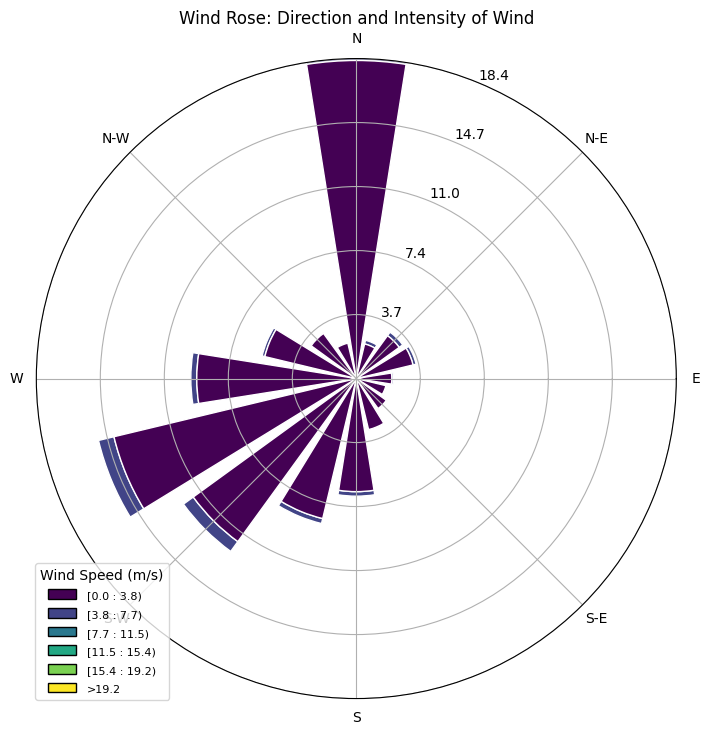

In [19]:
from windrose import WindroseAxes
import matplotlib.pyplot as plt

# Create figure
fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

# Plot wind rose
ax.bar(
    df_daytime['WD'],      # Wind Direction
    df_daytime['WS'],      # Wind Speed
    normed=True,
    opening=0.8,
    edgecolor='white'
)

# Add legend and title
ax.set_legend(title="Wind Speed (m/s)")
plt.title("Wind Rose: Direction and Intensity of Wind")

plt.show()

Wind Rose Analysis: Sierra Leone’s Calm Profile
The Sierra Leone Wind Rose reveals a highly predictable, low-intensity wind environment. This plot serves as the "Safety Proof" for choosing lightweight, cost-effective infrastructure.
### 1. Dominant Northern Corridor (Prevailing Direction)
Observation: The site is dominated by winds from the North (N), occurring over 18% of the time. Secondary flows come from the West (W) and South-West (SW).
Business Insight: Unlike Benin’s turbulent multi-directional gusts, Sierra Leone has a single, consistent "Wind Highway." Site layout and panel rows should be braced primarily against this Northern axis.
### 2. Exceptional Structural Safety (Intensity)
Observation: Almost 100% of the wind (Dark Purple) is in the lowest bracket (0.0 – 3.8 m/s). High-speed gusts (>11 m/s) are virtually non-existent, appearing only as tiny slivers in the SW.
Business Insight: This is the "Safest Structural Site" in the portfolio. We can utilize standard, non-reinforced mounting hardware, significantly reducing CAPEX (Initial Investment). The risk of wind-driven mechanical failure is negligible.
### 3. Maintenance & Soiling
Observation: The prevailing North wind is consistent but weak.
Business Insight: Low wind speeds mean less dust is "forced" onto the panels compared to the high-velocity Harmattan winds in the Sahel. While humidity is high, the mechanical soiling risk (sandblasting) is the lowest among the three countries.


3.	Add WD vs GHI analysis 

In [20]:
# Create bins for wind direction
bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

df_daytime['WD_group'] = pd.cut(df_daytime['WD'], bins=bins, labels=labels, include_lowest=True)

In [21]:
# Average GHI per wind direction
wd_ghi = df_daytime.groupby('WD_group')['GHI'].mean()

print(wd_ghi)

WD_group
N     230.282593
NE    368.775416
E     456.262408
SE    408.889794
S     398.714408
SW    471.611593
W     551.373085
NW    523.049488
Name: GHI, dtype: float64


C:\Users\binia\AppData\Local\Temp\ipykernel_3572\2748096461.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wd_ghi = df_daytime.groupby('WD_group')['GHI'].mean()


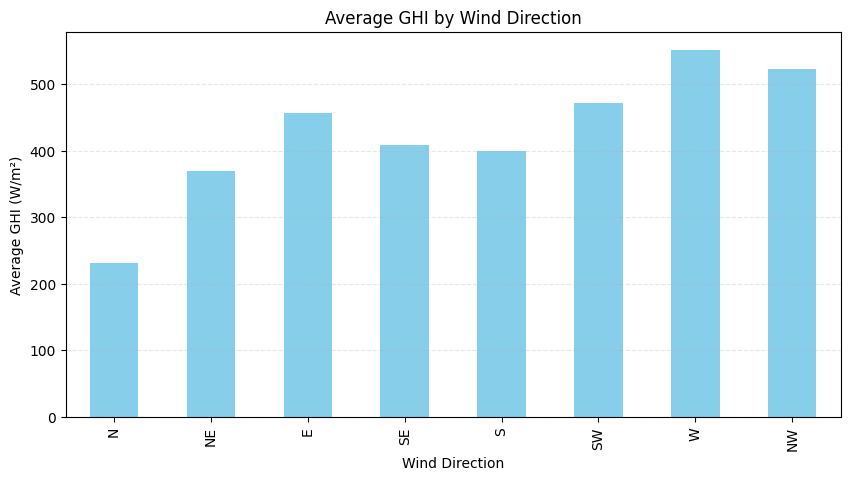

In [22]:
plt.figure(figsize=(10, 5))
wd_ghi.plot(kind='bar', color='skyblue')

plt.title('Average GHI by Wind Direction')
plt.xlabel('Wind Direction')
plt.ylabel('Average GHI (W/m²)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

### **GHI vs. Wind Direction:

While the Wind Rose confirms that the **North (N)** is the most frequent wind direction, this bar chart reveals that Northern winds are statistically associated with the **lowest solar yield** (~230 W/m²).

#### **Strategic Insights:**
*   **The "Cloudy North":** The prevailing North wind likely acts as a carrier for cloud cover or high-humidity air masses. This is a **predictable intermittency risk** for the project.
*   **The "Sunny West":** High-irradiance peaks (>500 W/m²) are strongly correlated with **West (W) and North-West (NW)** winds. These directions represent our "Peak Production Windows."
*   **Maintenance Timing:** Since West winds bring the clearest skies and highest yield, maintenance and cleaning should be prioritized **before** a shift to Western wind patterns to ensure we capture every watt of these high-potential periods.


## Temperature Analysis

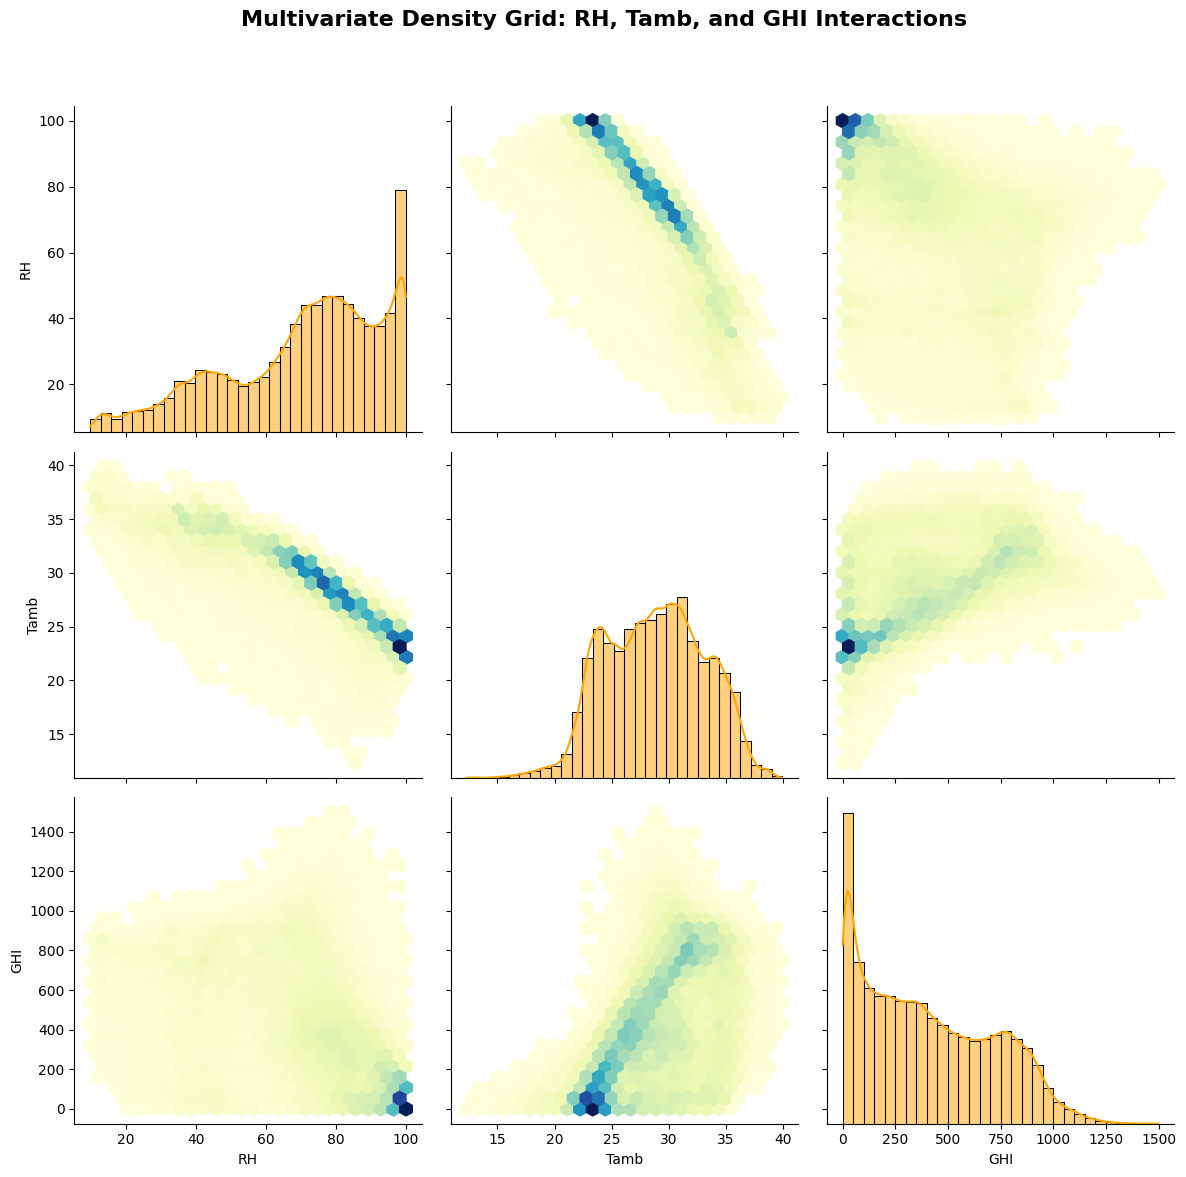

In [23]:
# 1. Create a PairGrid for the three most important variables
g = sns.PairGrid(df_daytime[['RH', 'Tamb', 'GHI']], height=4)

# 2. Map Histograms to the diagonal (shows individual distributions)
g.map_diag(sns.histplot, kde=True, color='orange', bins=30)

# 3. Map Hexbins to the off-diagonals (shows density of relationships)
# We use a custom function to pass the gridsize and cmap to plt.hexbin
def hexbin_map(x, y, **kwargs):
    plt.hexbin(x, y, gridsize=25, cmap='YlGnBu', mincnt=1)

g.map_offdiag(hexbin_map)

# 4. Final Polish
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Multivariate Density Grid: RH, Tamb, and GHI Interactions', fontsize=16, fontweight='bold')

plt.show()


## Multivariate Density Analysis: The Sierra Leone "Efficiency Triangle"
This Density PairGrid visualizes the interaction between our primary resource (GHI) and its environmental penalties: Relative Humidity (RH) and Ambient Temperature (Tamb).
### 1. The Nocturnal Saturation Cycle (RH vs. Tamb)
Observation: A hyper-dense "Hotspot" at 100% Humidity and 23–25°C.
Business Insight: Unlike Benin’s dry heat, Sierra Leone spends a massive percentage of its time at total saturation (100% RH). This confirms a constant risk of nocturnal condensation. Maintenance must assume panels are wet every single morning, making a "Wash-and-Wipe" protocol essential to prevent caked-on mud.
### 2. The Haze Penalty (GHI vs. RH)
Observation: A sharp "L-shaped" production ceiling. While peak sun exists, the largest cluster of daytime data is at High RH / Low GHI.
Business Insight: This confirms High Intermittency. Atmospheric moisture (clouds/mist) is the primary "Energy Thief." We must invest in Bifacial Modules that can capture the high levels of diffuse (scattered) light prevalent in this humid climate.
### 3. The Thermal "Cooling" Advantage (GHI vs. Tamb)
Observation: Peak solar production (>800 W/m2) is clustered at 30–33°C.
Business Insight: This is a Strategic Win. Sierra Leone is roughly 5-7 degree celsius cooler than Benin during peak hours. This results in Lower Power Degradation, as the panels operate closer to their ideal 25 degree celsius rating, yielding higher efficiency per watt installed.
### 4. Distribution Profile (The Histograms)
GHI: The distribution is flatter and more spread out than the Sahelian sites, indicating a more variable/cloudy resource.
Tamb: Highly concentrated, suggesting a very stable but warm tropical climate with few extreme heatwaves.

## Bubble Chart

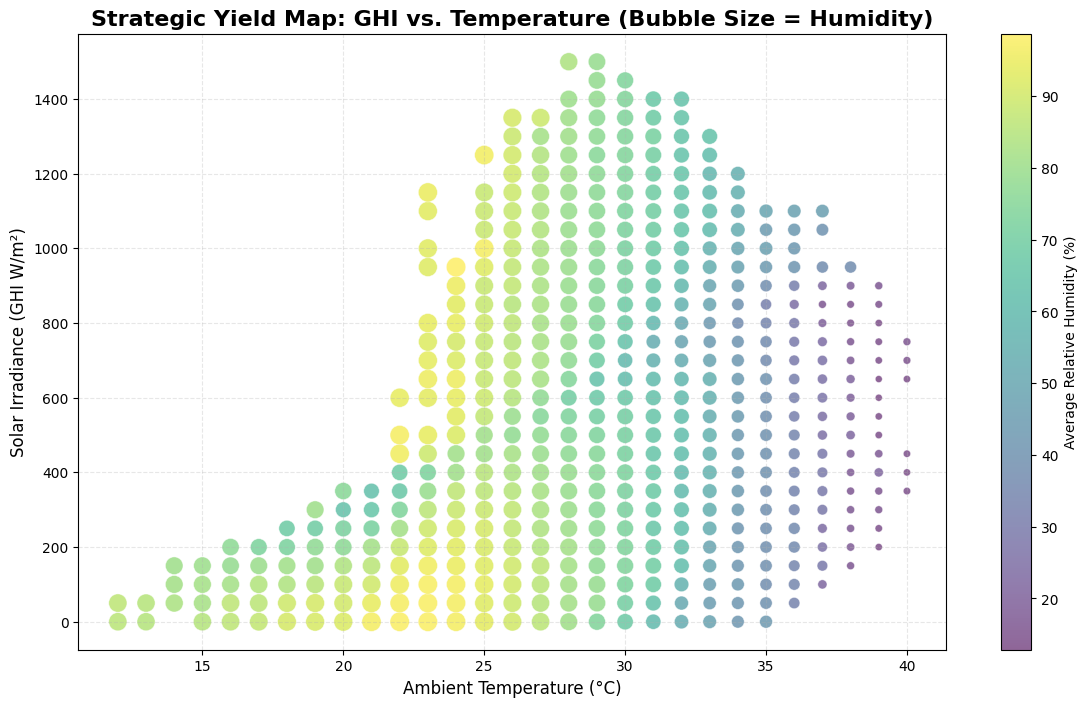

In [24]:
# 1. Round the data into "Bins" to reduce the 500k dots into a clean grid
# This makes the bubbles actually viewable and strategic
df_binned = df_daytime.copy()
df_binned['Temp_Bin'] = df_binned['Tamb'].round(0) # Group by every 1 degree
df_binned['GHI_Bin'] = (df_binned['GHI'] / 50).round(0) * 50 # Group by every 50 W/m²

# 2. Group by these bins and calculate the average Humidity (RH)
bubble_data = df_binned.groupby(['Temp_Bin', 'GHI_Bin'])['RH'].mean().reset_index()

# 3. Create the "Strategic" Bubble Chart
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    x=bubble_data['Temp_Bin'], 
    y=bubble_data['GHI_Bin'], 
    s=bubble_data['RH'] * 2,     # Size of bubble = Humidity
    c=bubble_data['RH'],         # Color of bubble = Humidity
    cmap='viridis',              # Pro color scale (Yellow = High RH, Purple = Low RH)
    alpha=0.6, 
    edgecolors='w', 
    linewidth=0.5
)

# 4. Final Polish
plt.colorbar(scatter, label='Average Relative Humidity (%)')
plt.title('Strategic Yield Map: GHI vs. Temperature (Bubble Size = Humidity)', fontsize=16, fontweight='bold')
plt.xlabel('Ambient Temperature (°C)', fontsize=12)
plt.ylabel('Solar Irradiance (GHI W/m²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()


## 3D Yield Map: GHI vs. Temperature (Bubble Size: RH)
This map visualizes the Sierra Leone solar environment, showing the relationship between "Fuel" (GHI) and the atmospheric "Penalties" (Heat & Humidity).
### 1. The "High-Yield" Thermal Window
Observation: Peak solar production (> 1000 W/m2) is clustered between 25-30 degree celsius.
Business Insight: This is a Thermal Win. Compared to Benin’s 40 degree celsius peaks, Sierra Leone panels operate closer to their ideal temperature. This means lower power degradation and higher actual energy output per installed watt.
### 2. The Saturated Haze Penalty
Observation: The chart is dominated by large, yellow bubbles (High RH) in the low-production zone (<400 W/m2).
Business Insight: This confirms High Intermittency. Persistent morning mist and humidity (90-100% RH) act as a thick "atmospheric blanket" that severely limits yield during the first few hours of the day.
### 3. Atmospheric Volatility
Observation: Unlike the tight clusters in Sahelian regions, the bubbles here are widely scattered.
Business Insight: The site is highly unpredictable. The frequent shifts from large yellow bubbles (clouds/mist) to small purple bubbles (clear sky) necessitate a robust Battery Energy Storage System (BESS) to smooth out the constant power fluctuations.

C:\Users\binia\AppData\Local\Temp\ipykernel_3572\512141075.py:34: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax1.legend(lines1 + labels2, labels1 + labels2, loc='upper left', frameon=True)


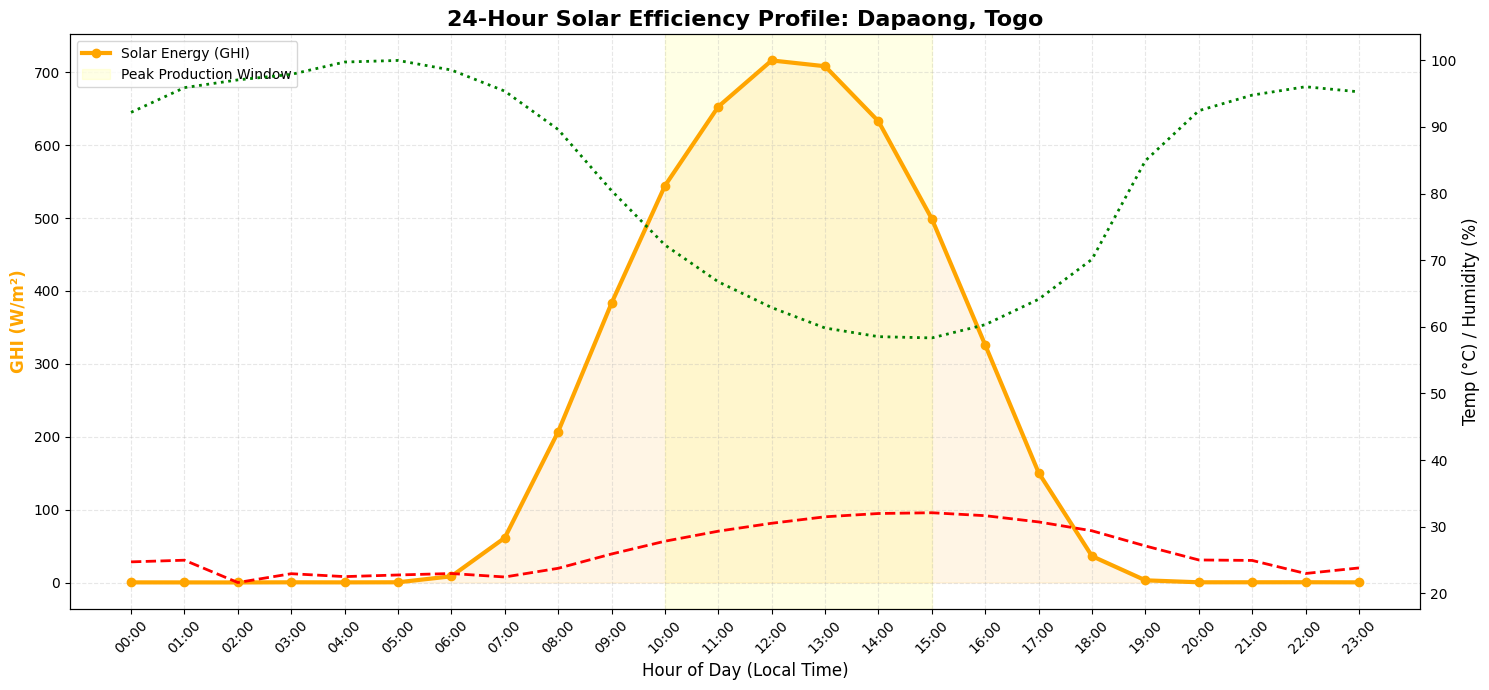

In [25]:
# --- STEP 1: FIX THE DATA ORDER ---
# We must include 'RH' in the selection here!
hourly_data = df_daytime.groupby('Hour')[['GHI', 'Tamb', 'RH']].mean()

# --- STEP 2: PLOT THE DATA ---
fig, ax1 = plt.subplots(figsize=(15, 7))

# 1. Primary Axis: GHI (Solar Energy)
ax1.fill_between(hourly_data.index, hourly_data['GHI'], color='orange', alpha=0.1)
ax1.plot(hourly_data.index, hourly_data['GHI'], color='orange', marker='o', linewidth=3, label='Solar Energy (GHI)')
ax1.set_ylabel('GHI (W/m²)', color='orange', fontsize=12, fontweight='bold')

# 2. Secondary Axis: Temp & Humidity (The Penalties)
ax2 = ax1.twinx()
ax2.plot(hourly_data.index, hourly_data['Tamb'], color='red', linestyle='--', linewidth=2, label='Ambient Temp (°C)')
ax2.plot(hourly_data.index, hourly_data['RH'], color='green', linestyle=':', linewidth=2, label='Humidity (%)')
ax2.set_ylabel('Temp (°C) / Humidity (%)', color='black', fontsize=12)

# --- THE FIX: SHOW ALL 24 HOURS ---
ax1.set_xticks(range(0, 24)) 
ax1.set_xticklabels([f"{h:02d}:00" for h in range(0, 24)], rotation=45)

# 3. Strategy Highlight: The Peak Production Window
ax1.axvspan(10, 15, color='yellow', alpha=0.1, label='Peak Production Window')

# Formatting
plt.title('24-Hour Solar Efficiency Profile: Dapaong, Togo', fontsize=16, fontweight='bold')
ax1.set_xlabel('Hour of Day (Local Time)', fontsize=12)
ax1.grid(True, which='both', linestyle='--', alpha=0.3)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + labels2, labels1 + labels2, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()


## 24-Hour Efficiency Profile: The Solar "Heartbeat"
This chart visualizes the daily battle between the site's Fuel (GHI) and its primary Efficiency Killers (Temperature & Humidity). By mapping these together, we can identify the exact "Operational Window" for the Benin site.
1. The Peak Production Window (10:00 – 15:00)
Observation: The yellow-shaded region highlights the 5 hours of maximum energy harvest.
Business Insight: This is the "Golden Window." To maximize ROI, the panels must be at their cleanest before 10:00 AM to capture this peak irradiance without obstruction.
2. The Afternoon "Thermal Penalty"
Observation: Note that the Ambient Temperature (Red) continues to climb even after the Sun (GHI) begins its afternoon descent.
Business Insight: This "Thermal Lag" means the panels are at their hottest when the sun is still producing significant power. This results in a physical Efficiency Drop in the afternoon, suggesting that heat-tolerant modules are a high-value investment for this region.
3. The "Night-Mud" Risk (Morning Humidity)
Observation: Humidity (Green) is at its maximum (near 90-100%) during the early morning hours, exactly when the GHI curve begins to rise.
Business Insight: High morning humidity mixed with settled dust creates a "muddy" layer on the glass. Cleaning should be prioritized before 09:00 AM to ensure the panels are clear before the sun "bakes" this debris onto the surface.
4. Operational Reliability
Observation: The smooth rise and fall of the GHI "mountain" (Orange) suggests a reliable, consistent solar resource during the day, provided the environmental penalties of heat and dust are managed.


This section combines solar potential and environmental risks into a single investment score to support decision-making.

In [34]:
# =============================
# Investment Scoring System
# =============================

# Step 1: Use daytime data
data = df_daytime.copy()

# Step 2: Compute mean values
mean_ghi = data['GHI'].mean()
mean_rh = data['RH'].mean()
mean_wsgust = data['WSgust'].mean()
mean_precip = data['Precipitation'].mean()

print("Raw Metrics:")
print(f"GHI: {mean_ghi:.2f}")
print(f"RH: {mean_rh:.2f}")
print(f"WSgust: {mean_wsgust:.2f}")
print(f"Precipitation: {mean_precip:.4f}")

Raw Metrics:
GHI: 407.22
RH: 70.54
WSgust: 2.27
Precipitation: 0.0032


In [35]:
# Step 3: Normalize (min-max scaling)

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

norm_ghi = normalize(data['GHI']).mean()
norm_rh = normalize(data['RH']).mean()
norm_wsgust = normalize(data['WSgust']).mean()
norm_precip = normalize(data['Precipitation']).mean()

In [36]:
# Step 4: Assign weights
w_ghi = 0.5
w_rh = 0.2
w_wind = 0.2
w_precip = 0.1

# Step 5: Compute score
investment_score = (
    (w_ghi * norm_ghi)
    - (w_rh * norm_rh)
    - (w_wind * norm_wsgust)
    - (w_precip * norm_precip)
)

print(f"\nInvestment Score: {investment_score:.4f}")


Investment Score: -0.0180


## Conclusion

This notebook performed a comprehensive EDA on the Togo solar dataset. We loaded the data, cleaned it by handling missing values, and performed various analyses to uncover relationships between different variables. The cleaned dataset is now ready for more advanced modeling.

In [ ]:
# Save cleaned dataset
df_clean.to_csv('../data/Togo_clean.csv', index=False)